# Pelabelan Topik LDA & Analisis Wacana Publik
## Program Makan Bergizi Gratis (MBG) — Komentar YouTube

Notebook ini melakukan:
1. **Pelabelan topik** hasil LDA ke nama tematik yang bermakna
2. **Eksplorasi data** distribusi topik, sumber, dan waktu
3. **Visualisasi lengkap** untuk keperluan laporan thesis
4. **Ekspor** dataset berlabel untuk analisis lanjutan

---
**Label Topik (ditetapkan berdasarkan analisis pyLDAvis):**

| Topik (LDA) | Label Tematik |
|:-----------:|:---|
| 0 | Dampak Ekonomi & Ketenagakerjaan |
| 1 | Wacana Politik & Evaluasi Kebijakan |
| 2 | Implementasi Sekolah & Keamanan Pangan |
| 3 | Tata Kelola & Akuntabilitas Dana |

## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# ── Styling global ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# ── Palet warna konsisten per topik ─────────────────────────────────────────
TOPIC_COLORS = {
    0: '#1D9E75',   # teal   — Ekonomi
    1: '#D85A30',   # coral  — Politik
    2: '#BA7517',   # amber  — Sekolah/Pangan
    3: '#534AB7',   # purple — Tata Kelola
}

TOPIC_LABELS = {
    0: 'Dampak Ekonomi &\nKetenagakerjaan',
    1: 'Wacana Politik &\nEvaluasi Kebijakan',
    2: 'Implementasi Sekolah &\nKeamanan Pangan',
    3: 'Tata Kelola &\nAkuntabilitas Dana',
}

TOPIC_LABELS_SHORT = {
    0: 'Ekonomi & Kerja',
    1: 'Politik & Kebijakan',
    2: 'Sekolah & Pangan',
    3: 'Tata Kelola & Dana',
}

print('✓ Library dan konfigurasi berhasil dimuat.')

✓ Library dan konfigurasi berhasil dimuat.


## 1. Load & Labeling Data

In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('comments_with_topics.csv')

# ── Parsing tanggal ──────────────────────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', utc=True)
df['YearMonth'] = df['Date'].dt.to_period('M')

# ── Pelabelan topik ──────────────────────────────────────────────────────────
df['topic_label'] = df['dominant_topic'].map(TOPIC_LABELS)
df['topic_label_short'] = df['dominant_topic'].map(TOPIC_LABELS_SHORT)
df['topic_color'] = df['dominant_topic'].map(TOPIC_COLORS)

# ── Kategori kepercayaan assignment ─────────────────────────────────────────
def confidence_category(p):
    if p >= 0.80:
        return 'Tinggi (≥0.80)'
    elif p >= 0.60:
        return 'Sedang (0.60–0.80)'
    else:
        return 'Rendah (<0.60)'

df['confidence_cat'] = df['dominant_topic_probability'].apply(confidence_category)

print(f'Total komentar : {len(df):,}')
print(f'Rentang waktu  : {df["Date"].min().date()} s.d. {df["Date"].max().date()}')
print(f'Sumber video   : {df["source"].nunique()} channel')
print()
print('Distribusi per topik:')
summary = (df.groupby(['dominant_topic', 'topic_label_short'])
             .size()
             .reset_index(name='n'))
summary['%'] = (summary['n'] / len(df) * 100).round(1)
summary['mean_prob'] = (df.groupby('dominant_topic')['dominant_topic_probability']
                          .mean().values.round(3))
print(summary.to_string(index=False))

Total komentar : 6,805
Rentang waktu  : 2025-01-05 s.d. 2026-06-01
Sumber video   : 5 channel

Distribusi per topik:
 dominant_topic   topic_label_short    n    %  mean_prob
              0     Ekonomi & Kerja 1458 21.4      0.767
              1 Politik & Kebijakan 1381 20.3      0.777
              2    Sekolah & Pangan 2387 35.1      0.799
              3  Tata Kelola & Dana 1579 23.2      0.772


In [3]:
# Preview dataset berlabel
cols_preview = ['Comment', 'Date', 'source', 'dominant_topic',
                'dominant_topic_probability', 'topic_label_short', 'confidence_cat']
df[cols_preview].head(10)

,Comment,Date,source,dominant_topic,dominant_topic_probability,topic_label_short,confidence_cat
0,Gini dong jadi pejabat klu bohong jangan pakai...,2026-02-13 19:46:52+00:00,Merdeka,0,0.613645,Ekonomi & Kerja,Sedang (0.60–0.80)
1,Begitu ternyata cara mereka kerja meskipun fak...,2026-01-13 08:42:21+00:00,Merdeka,1,0.973688,Politik & Kebijakan,Tinggi (≥0.80)
2,Pelayanan dan imformasi pihak BGN di daerah ti...,2026-01-05 02:50:32+00:00,Merdeka,0,0.585911,Ekonomi & Kerja,Rendah (<0.60)
3,"Disaat MBG menyerap ayam, susu, ikan, daging, ...",2025-12-30 02:00:02+00:00,Merdeka,2,0.588147,Sekolah & Pangan,Rendah (<0.60)
4,"Laporkan juga menu roti 1000, buah potong 3 up...",2025-12-29 22:02:10+00:00,Merdeka,2,0.684596,Sekolah & Pangan,Sedang (0.60–0.80)
5,daerah saya gk ada nasi goreng pas pak Preside...,2025-12-25 10:20:06+00:00,Merdeka,1,0.552953,Politik & Kebijakan,Rendah (<0.60)
6,50 orang yang kerja itu para penjilat mbg buka...,2025-12-25 06:15:17+00:00,Merdeka,0,0.886785,Ekonomi & Kerja,Tinggi (≥0.80)
7,Pembohongan gila 58 triliunan uang rakyat dipa...,2025-12-24 22:02:35+00:00,Merdeka,3,0.558588,Tata Kelola & Dana,Rendah (<0.60)
8,"Itu laporanya bohong pak, coba cek aja 1 hari ...",2025-12-23 06:26:48+00:00,Merdeka,0,0.953120,Ekonomi & Kerja,Tinggi (≥0.80)
9,Bohongggg.. bapak president harus terjun langs...,2025-12-22 15:44:18+00:00,Merdeka,1,0.480052,Politik & Kebijakan,Rendah (<0.60)


## 2. Distribusi Topik

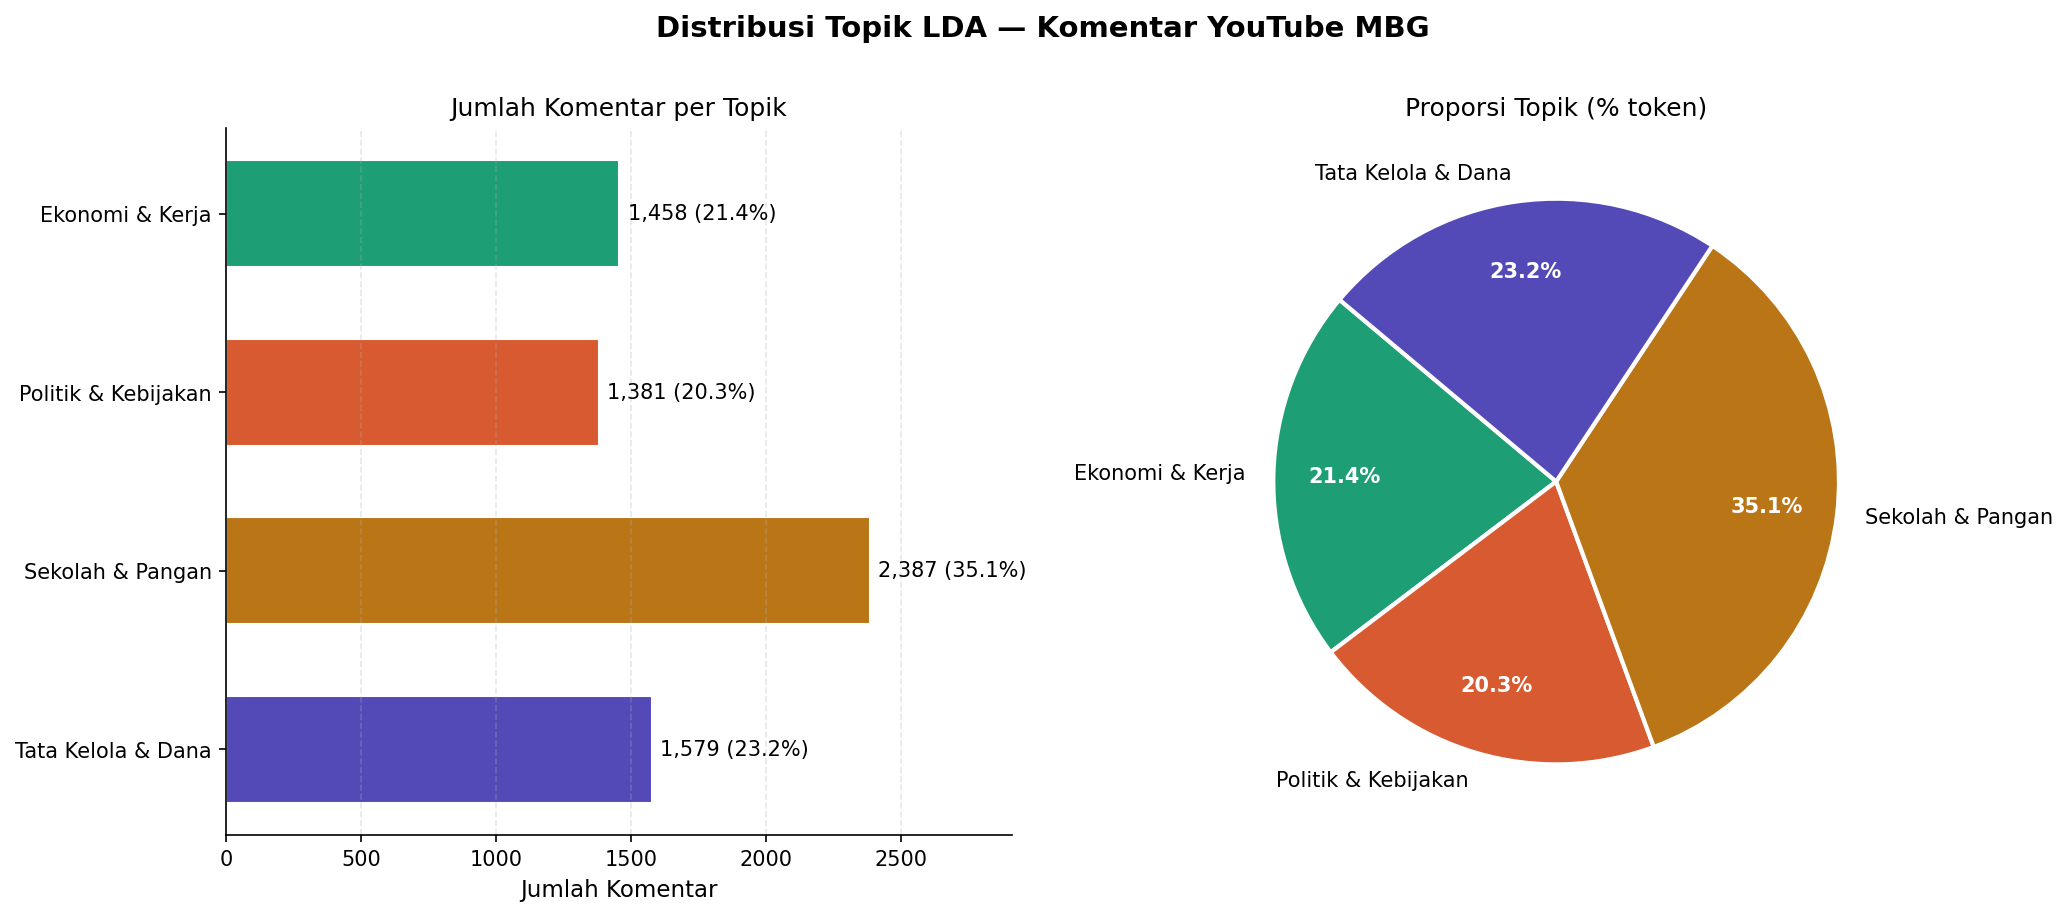

✓ Disimpan: fig1_distribusi_topik.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Topik LDA — Komentar YouTube MBG',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel kiri: Bar chart jumlah komentar ────────────────────────────────────
ax1 = axes[0]
counts = df['dominant_topic'].value_counts().sort_index()
bars = ax1.barh(
    [TOPIC_LABELS_SHORT[i] for i in counts.index],
    counts.values,
    color=[TOPIC_COLORS[i] for i in counts.index],
    edgecolor='white', height=0.6
)
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)', va='center', fontsize=10)
ax1.set_xlabel('Jumlah Komentar', fontsize=11)
ax1.set_title('Jumlah Komentar per Topik', fontsize=12)
ax1.set_xlim(0, counts.max() * 1.22)
ax1.invert_yaxis()
ax1.grid(axis='y', alpha=0)

# ── Panel kanan: Pie chart proporsi ─────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=[TOPIC_LABELS_SHORT[i] for i in counts.index],
    colors=[TOPIC_COLORS[i] for i in counts.index],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')
ax2.set_title('Proporsi Topik (% token)', fontsize=12)

plt.tight_layout()
plt.savefig('fig1_distribusi_topik.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig1_distribusi_topik.png')

## 3. Distribusi Probabilitas Penugasan Topik

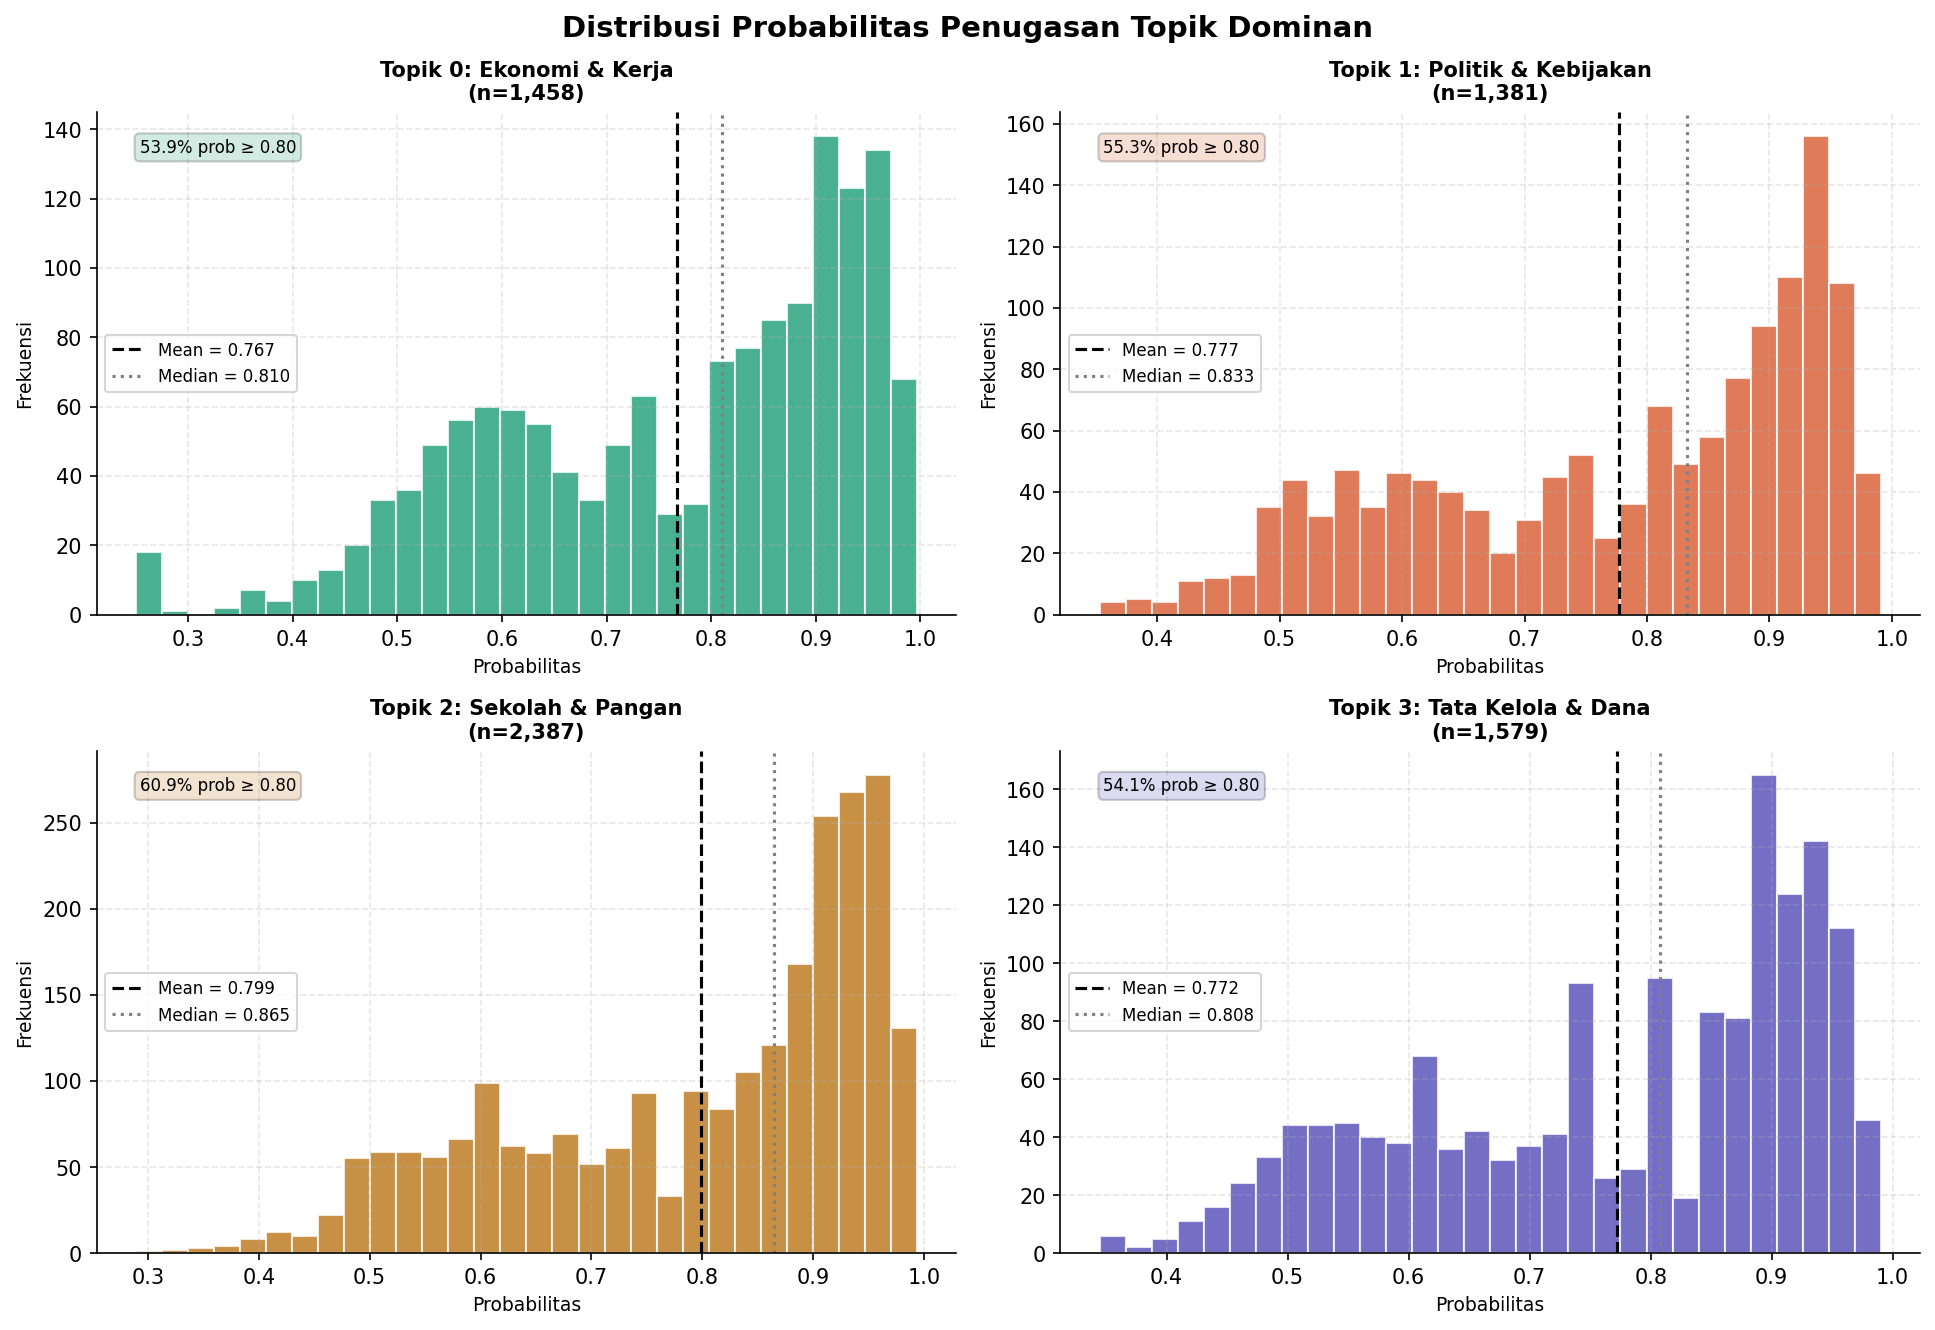

✓ Disimpan: fig2_distribusi_probabilitas.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribusi Probabilitas Penugasan Topik Dominan',
             fontsize=14, fontweight='bold')

for idx, topic_id in enumerate([0, 1, 2, 3]):
    ax = axes[idx // 2][idx % 2]
    data = df[df['dominant_topic'] == topic_id]['dominant_topic_probability']
    color = TOPIC_COLORS[topic_id]

    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean = {data.mean():.3f}')
    ax.axvline(data.median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Median = {data.median():.3f}')

    ax.set_title(f'Topik {topic_id}: {TOPIC_LABELS_SHORT[topic_id]}\n(n={len(data):,})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Probabilitas', fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=8)

    # Anotasi persentase high confidence
    high_conf = (data >= 0.80).sum() / len(data) * 100
    ax.text(0.05, 0.92, f'{high_conf:.1f}% prob ≥ 0.80',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.2))

plt.tight_layout()
plt.savefig('fig2_distribusi_probabilitas.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig2_distribusi_probabilitas.png')

## 4. Distribusi Topik per Sumber Video

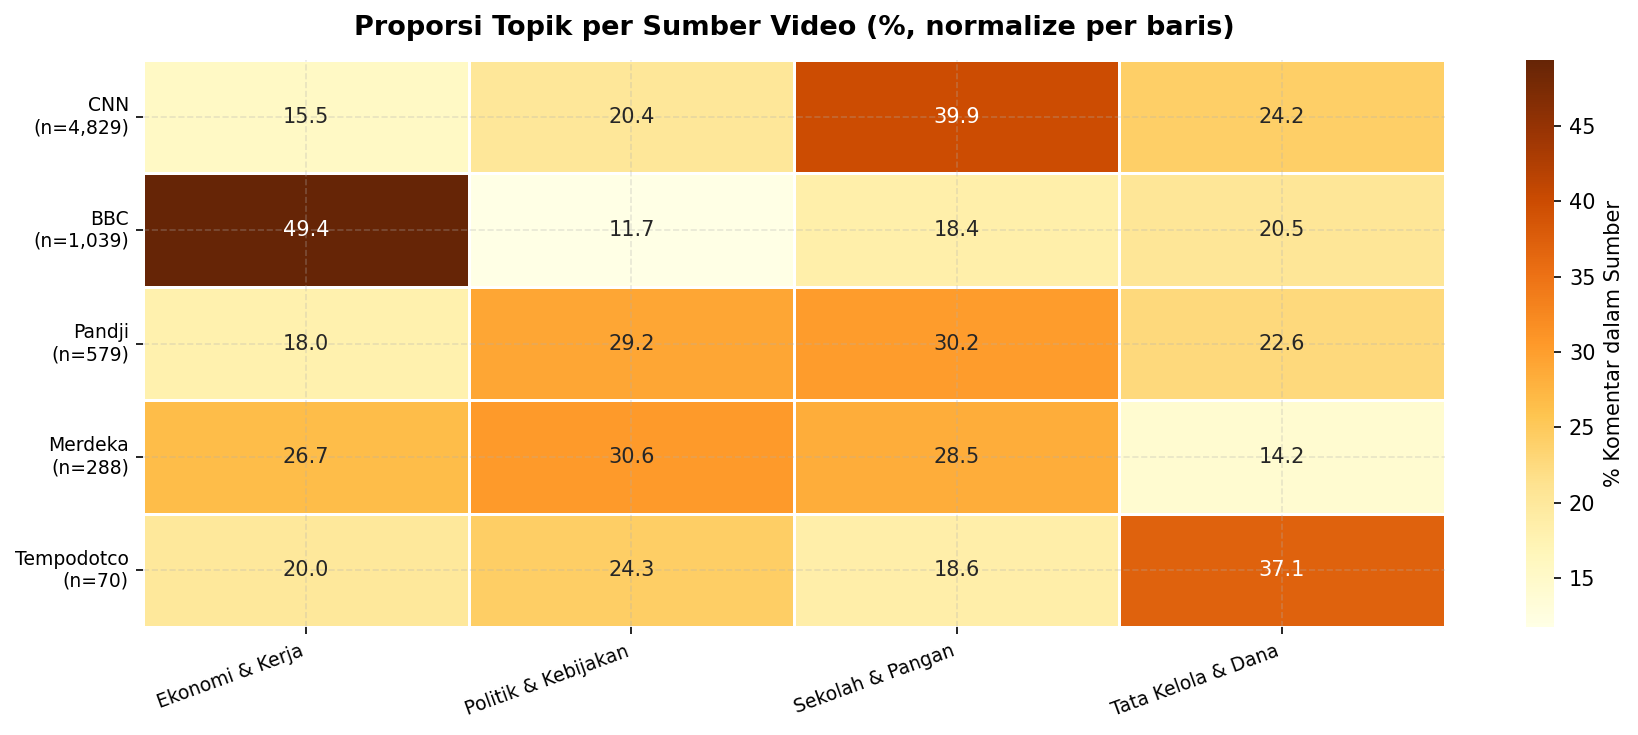

✓ Disimpan: fig3_heatmap_sumber_topik.png


In [6]:
# ── Heatmap proporsi topik per sumber ───────────────────────────────────────
crosstab = pd.crosstab(
    df['source'],
    df['topic_label_short'],
    normalize='index'
) * 100

# Urutkan kolom sesuai topik
col_order = [TOPIC_LABELS_SHORT[i] for i in range(4)]
crosstab = crosstab[col_order]

# Urutkan baris berdasarkan jumlah komentar
source_order = df['source'].value_counts().index.tolist()
crosstab = crosstab.reindex(source_order)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='.1f',
    cmap='YlOrBr',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': '% Komentar dalam Sumber'},
    annot_kws={'size': 10}
)

# Tambahkan jumlah total per sumber di label y
source_counts = df['source'].value_counts()
new_ylabels = [f"{src}\n(n={source_counts[src]:,})" for src in source_order]
ax.set_yticklabels(new_ylabels, rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax.set_title('Proporsi Topik per Sumber Video (%, normalize per baris)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('fig3_heatmap_sumber_topik.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig3_heatmap_sumber_topik.png')

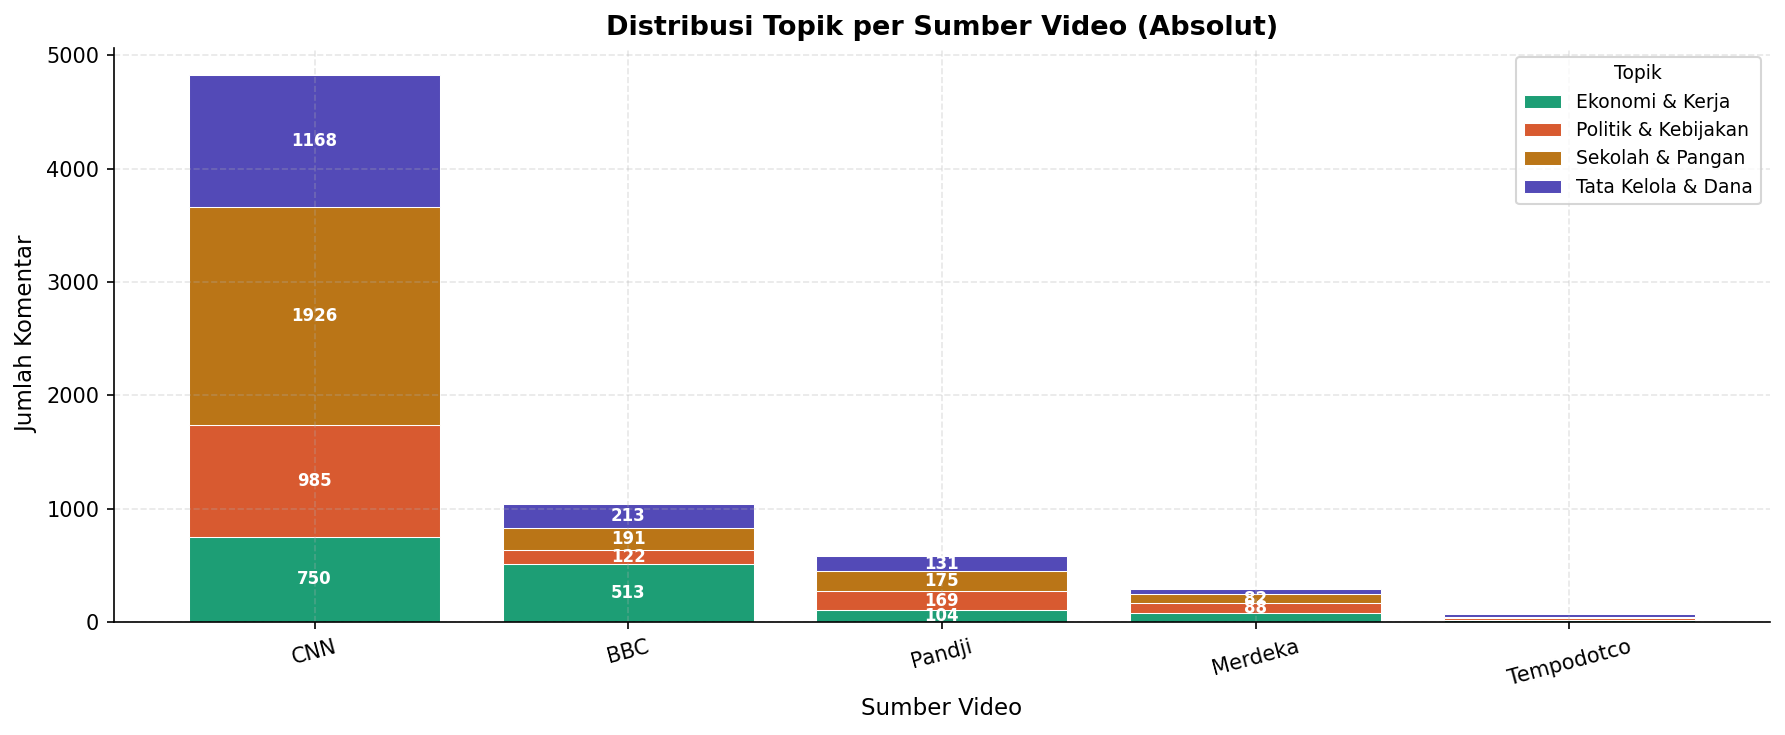

✓ Disimpan: fig4_stacked_bar_sumber.png


In [7]:
# ── Stacked bar chart per sumber ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

crosstab_abs = pd.crosstab(df['source'], df['dominant_topic'])
crosstab_abs = crosstab_abs.reindex(source_order)

bottom = np.zeros(len(crosstab_abs))
for topic_id in range(4):
    vals = crosstab_abs[topic_id].values
    ax.bar(
        crosstab_abs.index,
        vals,
        bottom=bottom,
        color=TOPIC_COLORS[topic_id],
        label=TOPIC_LABELS_SHORT[topic_id],
        edgecolor='white', linewidth=0.5
    )
    # Label nilai jika cukup besar
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 80:
            ax.text(i, b + v/2, str(v), ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xlabel('Sumber Video', fontsize=11)
ax.set_ylabel('Jumlah Komentar', fontsize=11)
ax.set_title('Distribusi Topik per Sumber Video (Absolut)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, title='Topik', title_fontsize=9)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig4_stacked_bar_sumber.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig4_stacked_bar_sumber.png')

## 5. Tren Topik Berdasarkan Waktu

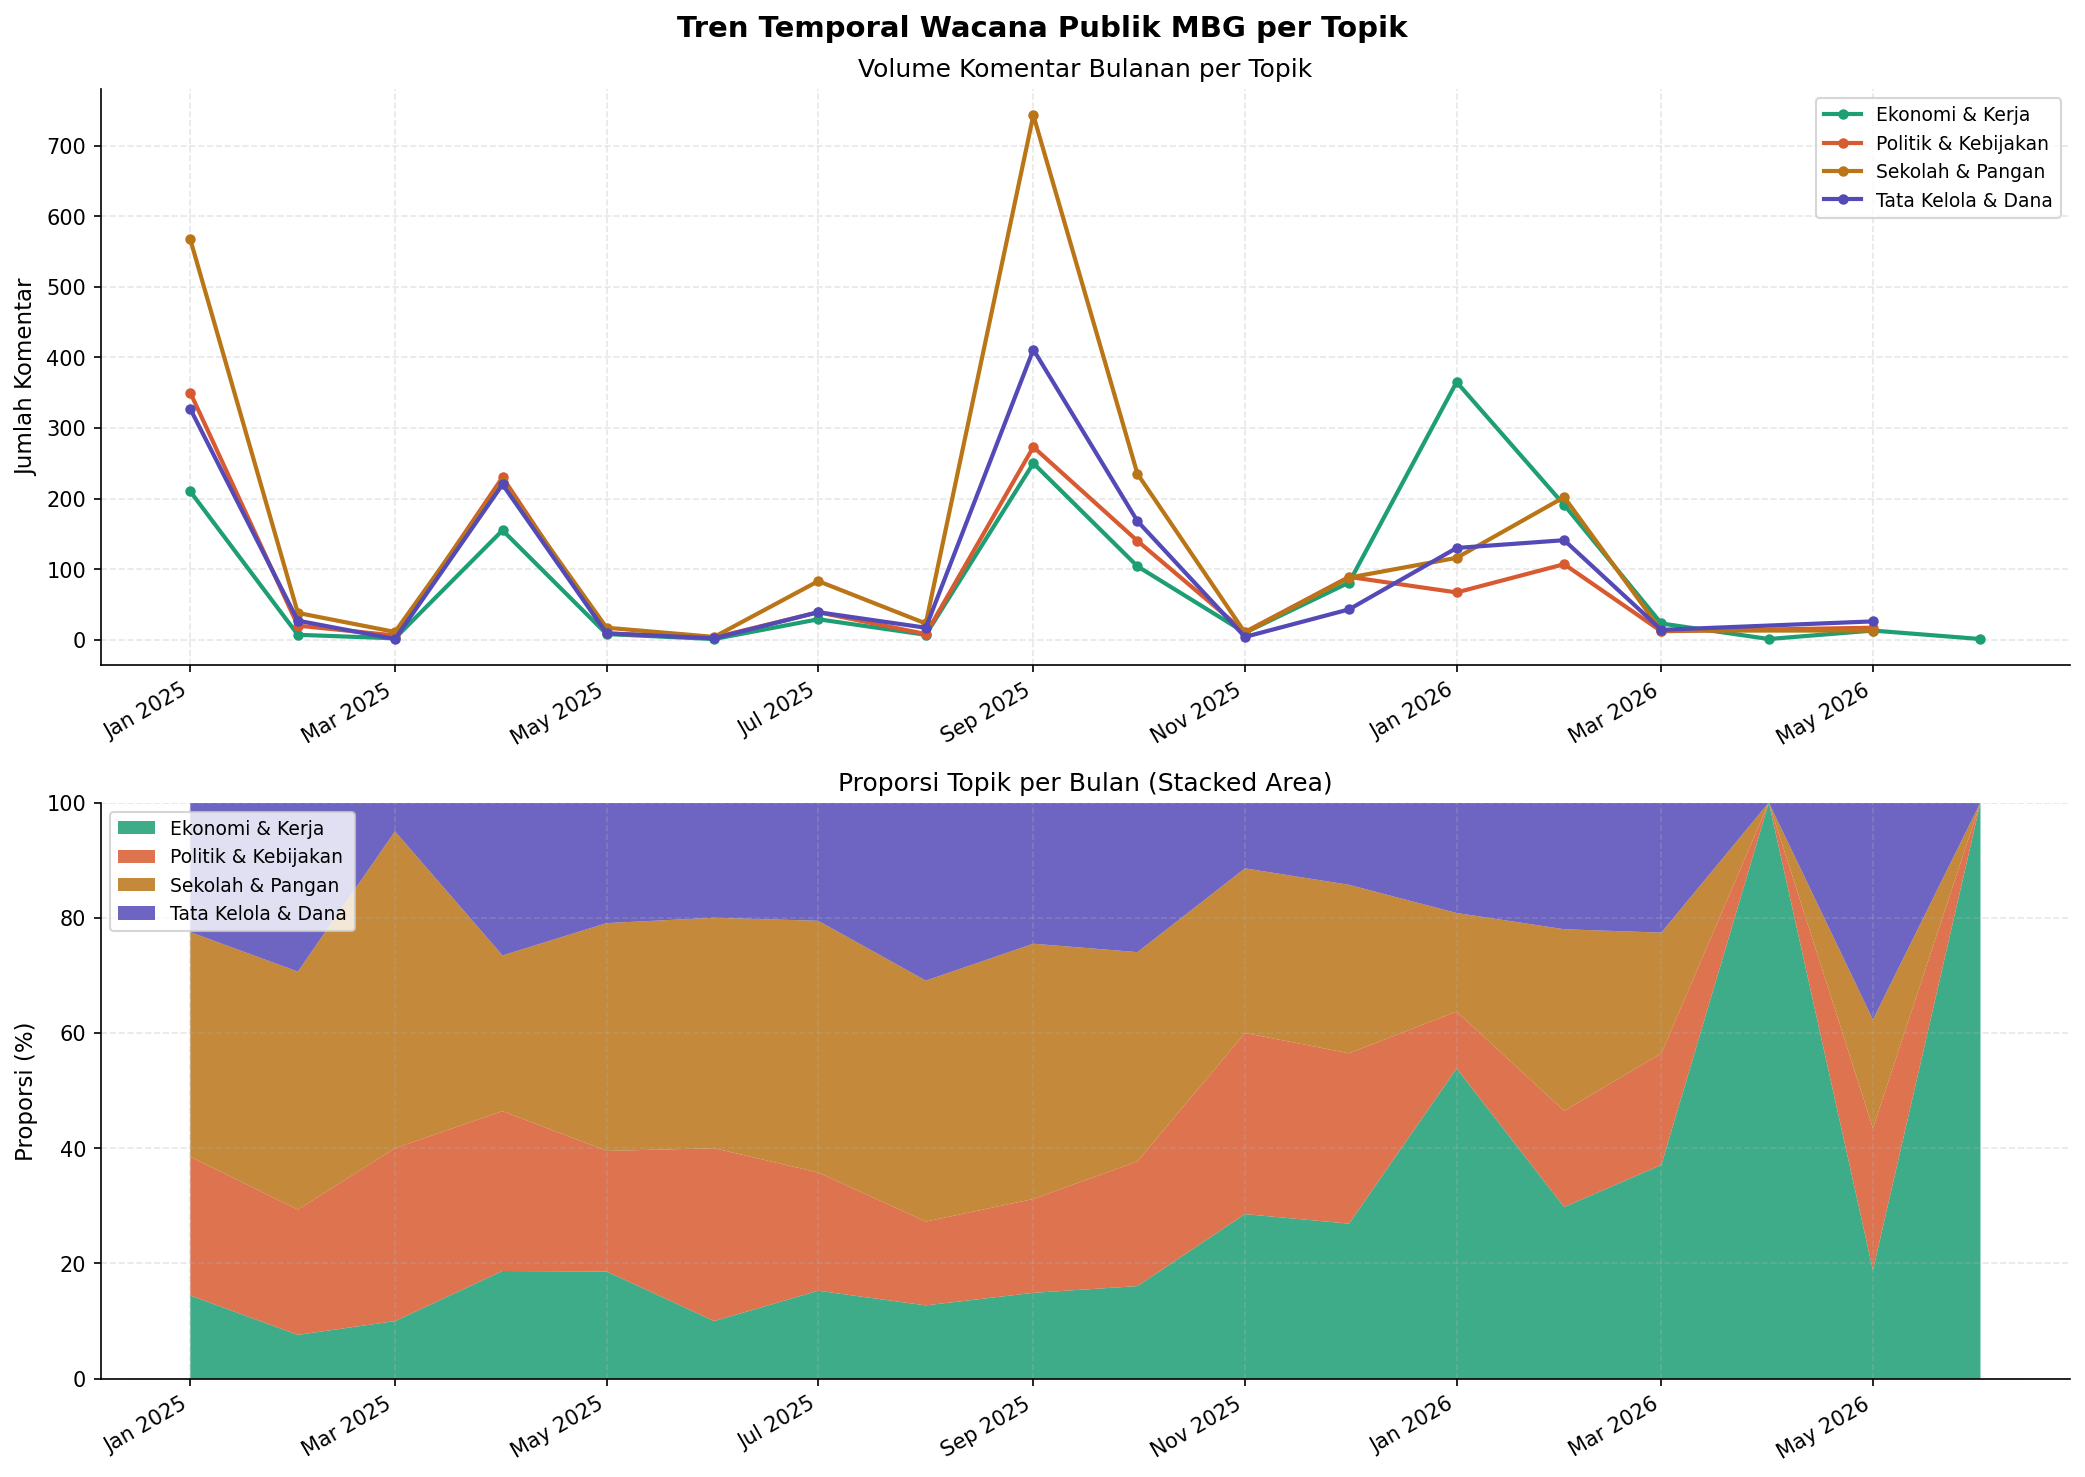

✓ Disimpan: fig5_tren_temporal.png


In [8]:
# ── Tren bulanan per topik ────────────────────────────────────────────────────
df_dated = df.dropna(subset=['Date']).copy()
df_dated['YearMonth'] = df_dated['Date'].dt.to_period('M')

monthly = (df_dated
           .groupby(['YearMonth', 'dominant_topic'])
           .size()
           .reset_index(name='count'))
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Tren Temporal Wacana Publik MBG per Topik',
             fontsize=14, fontweight='bold')

# ── Panel atas: Line chart absolut ───────────────────────────────────────────
ax1 = axes[0]
for topic_id in range(4):
    sub = monthly[monthly['dominant_topic'] == topic_id]
    ax1.plot(
        sub['YearMonth_dt'], sub['count'],
        color=TOPIC_COLORS[topic_id],
        label=TOPIC_LABELS_SHORT[topic_id],
        marker='o', markersize=4, linewidth=2
    )
ax1.set_ylabel('Jumlah Komentar', fontsize=11)
ax1.set_title('Volume Komentar Bulanan per Topik', fontsize=12)
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Panel bawah: Stacked area chart proporsi ─────────────────────────────────
ax2 = axes[1]
monthly_pct = monthly.pivot(index='YearMonth_dt', columns='dominant_topic', values='count').fillna(0)
monthly_pct_norm = monthly_pct.div(monthly_pct.sum(axis=1), axis=0) * 100

ax2.stackplot(
    monthly_pct_norm.index,
    [monthly_pct_norm[t] for t in range(4)],
    labels=[TOPIC_LABELS_SHORT[t] for t in range(4)],
    colors=[TOPIC_COLORS[t] for t in range(4)],
    alpha=0.85
)
ax2.set_ylabel('Proporsi (%)', fontsize=11)
ax2.set_ylim(0, 100)
ax2.set_title('Proporsi Topik per Bulan (Stacked Area)', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig5_tren_temporal.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig5_tren_temporal.png')

## 6. Word Cloud per Topik

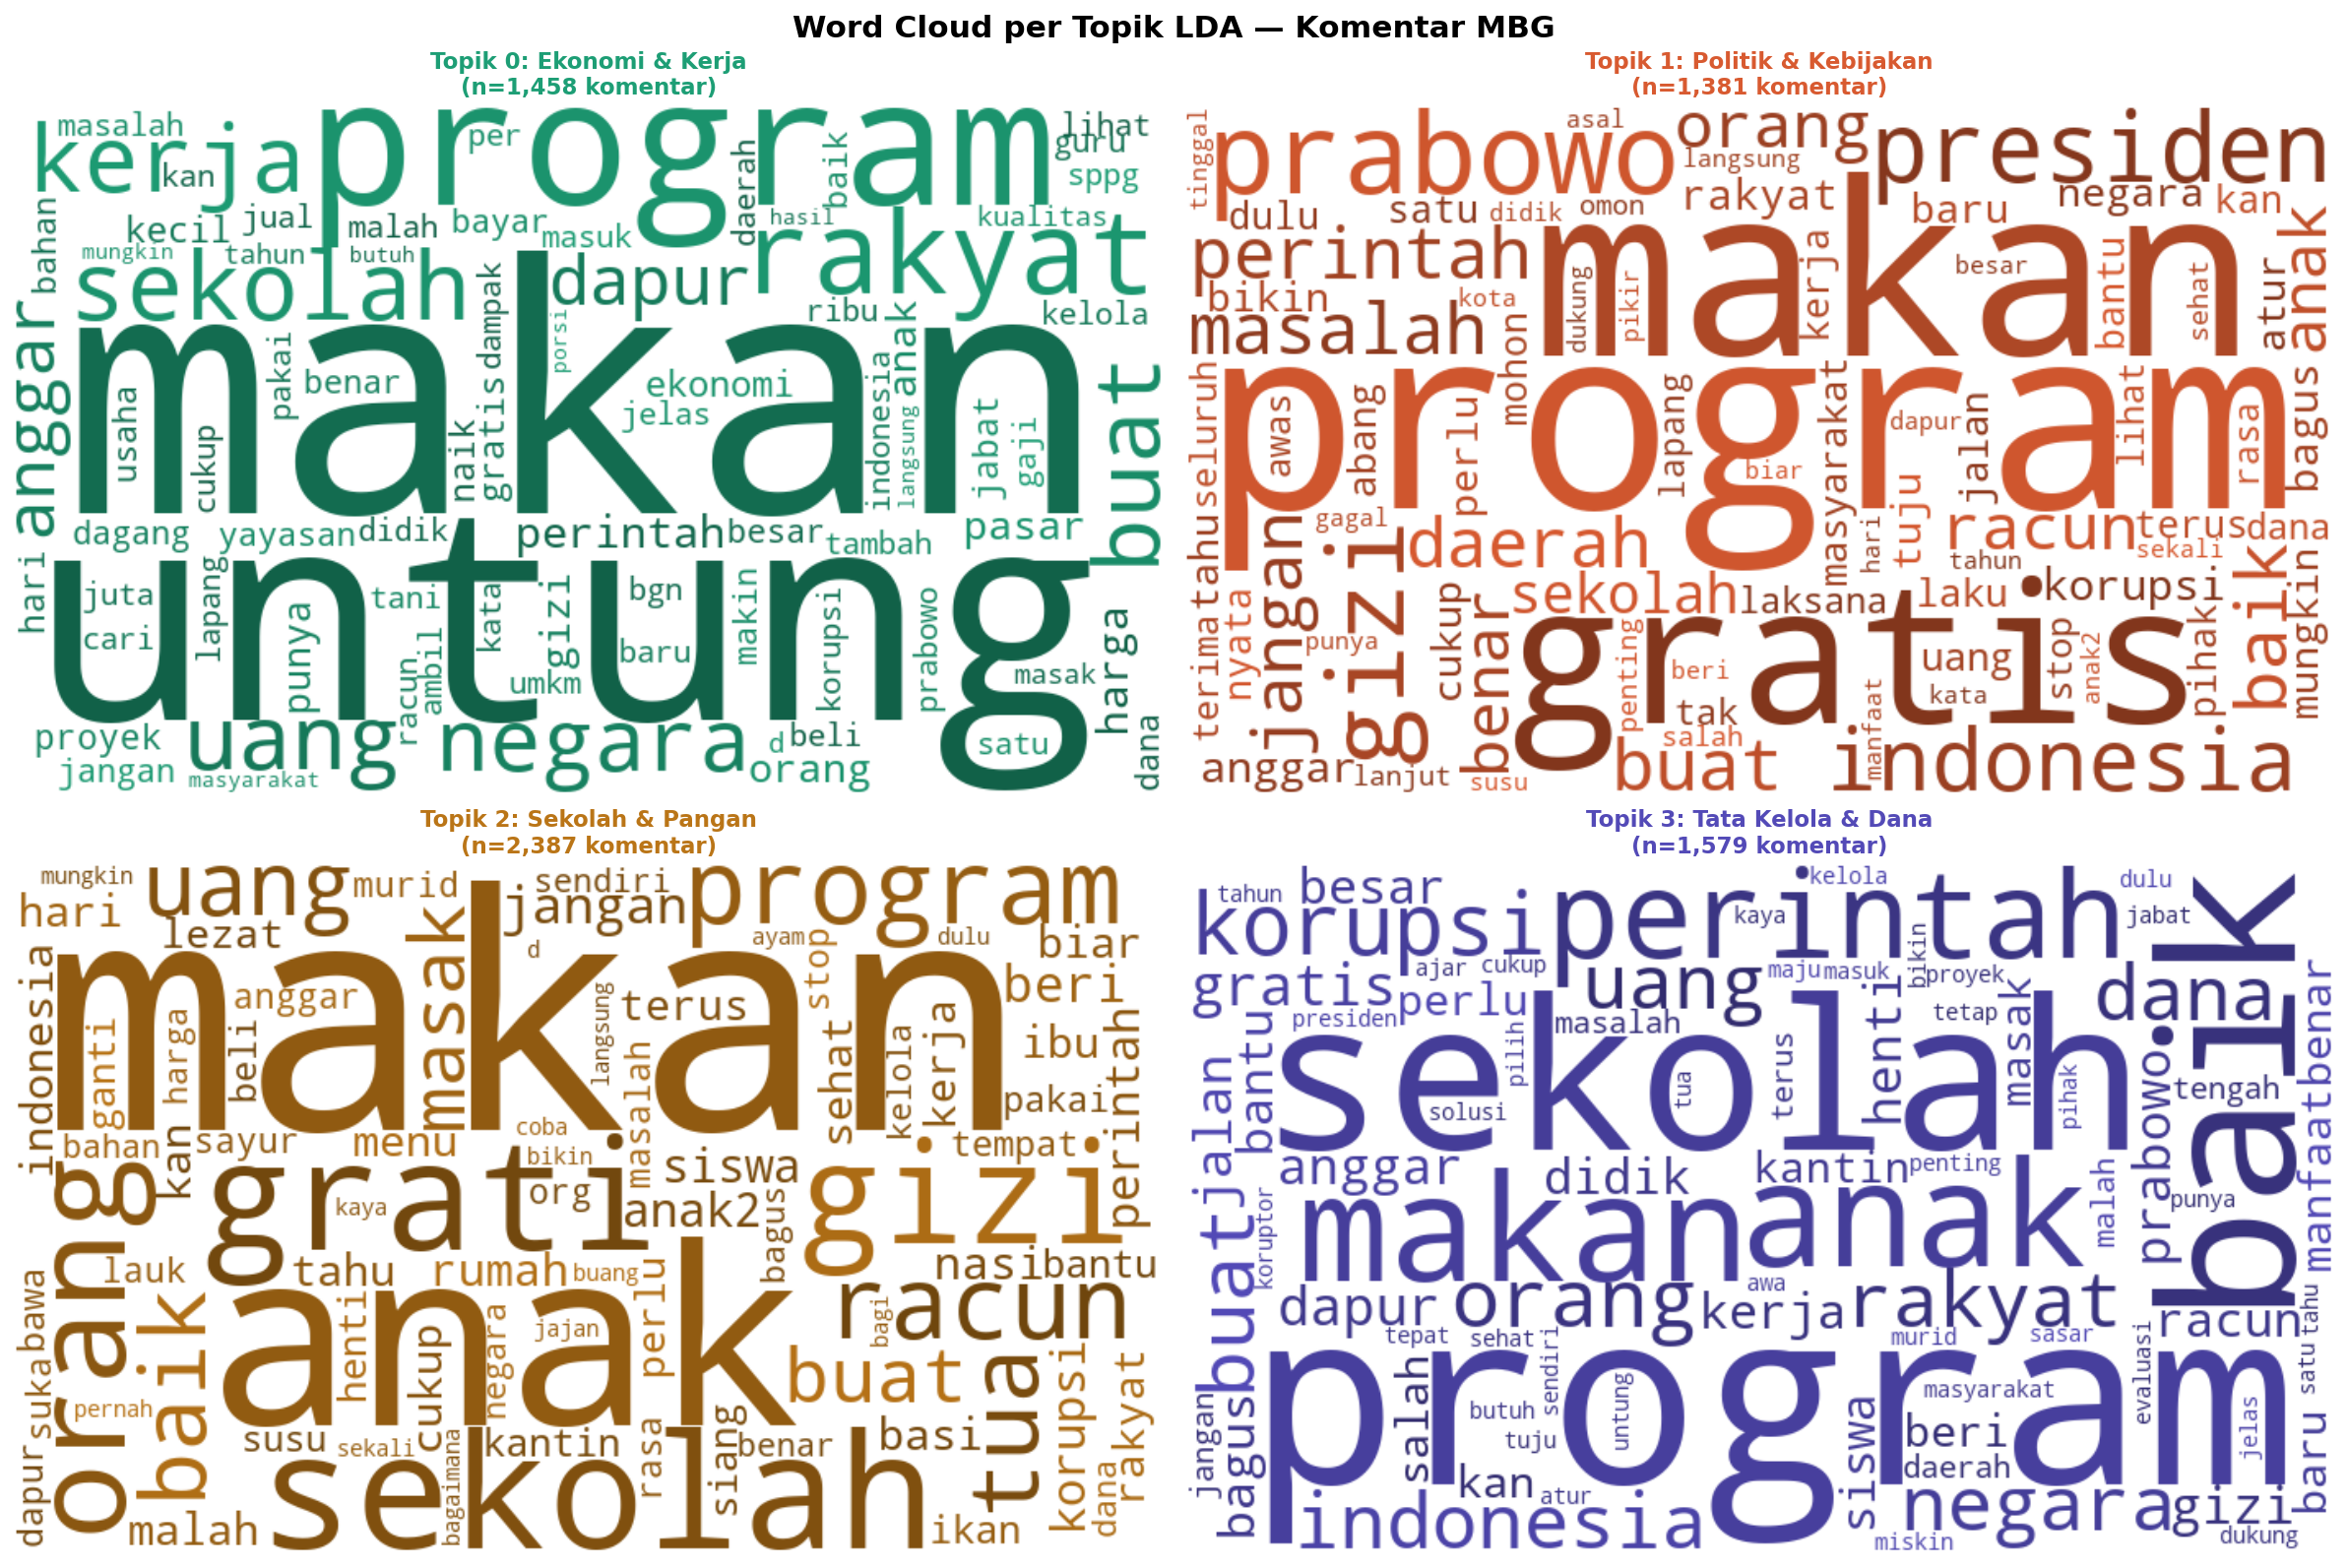

✓ Disimpan: fig6_wordcloud_topik.png


In [9]:
# ── Word Cloud dari processed_comment per topik ──────────────────────────────
# Stopwords bahasa Indonesia umum (non-domain)
STOPWORDS_ID = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan',
    'untuk', 'pada', 'adalah', 'tidak', 'ada', 'juga', 'sudah',
    'saya', 'kami', 'kita', 'mereka', 'dia', 'kamu', 'anda',
    'akan', 'bisa', 'bukan', 'karena', 'tapi', 'atau', 'jika',
    'bila', 'kalau', 'agar', 'supaya', 'lebih', 'sangat', 'sudah',
    'lagi', 'pun', 'ya', 'pak', 'bu', 'mas', 'mbak', 'bang',
    'dong', 'deh', 'sih', 'loh', 'nih', 'kak', 'nya', 'lah',
    'hal', 'aja', 'jadi', 'memang', 'paling', 'mana', 'saja',
    'semua', 'setiap', 'tiap', 'banyak', 'harus', 'boleh',
])

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Word Cloud per Topik LDA — Komentar MBG',
             fontsize=15, fontweight='bold')

for idx, topic_id in enumerate([0, 1, 2, 3]):
    ax = axes[idx // 2][idx % 2]
    text_corpus = ' '.join(
        df[df['dominant_topic'] == topic_id]['processed_comment'].dropna().tolist()
    )
    color = TOPIC_COLORS[topic_id]

    # Buat colormap satu warna
    def make_color_func(base_color):
        import matplotlib.colors as mcolors
        rgb = mcolors.to_rgb(base_color)
        def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
            r = int(rgb[0] * 255)
            g = int(rgb[1] * 255)
            b = int(rgb[2] * 255)
            # variasi kecerahan
            factor = np.random.uniform(0.6, 1.0)
            return f'rgb({int(r*factor)},{int(g*factor)},{int(b*factor)})'
        return color_func

    wc = WordCloud(
        width=700, height=420,
        background_color='white',
        max_words=80,
        stopwords=STOPWORDS_ID,
        collocations=False,
        color_func=make_color_func(color),
        prefer_horizontal=0.7,
        min_font_size=8,
    ).generate(text_corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(
        f'Topik {topic_id}: {TOPIC_LABELS_SHORT[topic_id]}\n'
        f'(n={len(df[df["dominant_topic"]==topic_id]):,} komentar)',
        fontsize=11, fontweight='bold', color=color
    )
    ax.axis('off')
    # Border berwarna
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('fig6_wordcloud_topik.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig6_wordcloud_topik.png')

## 7. Analisis Panjang Komentar per Topik

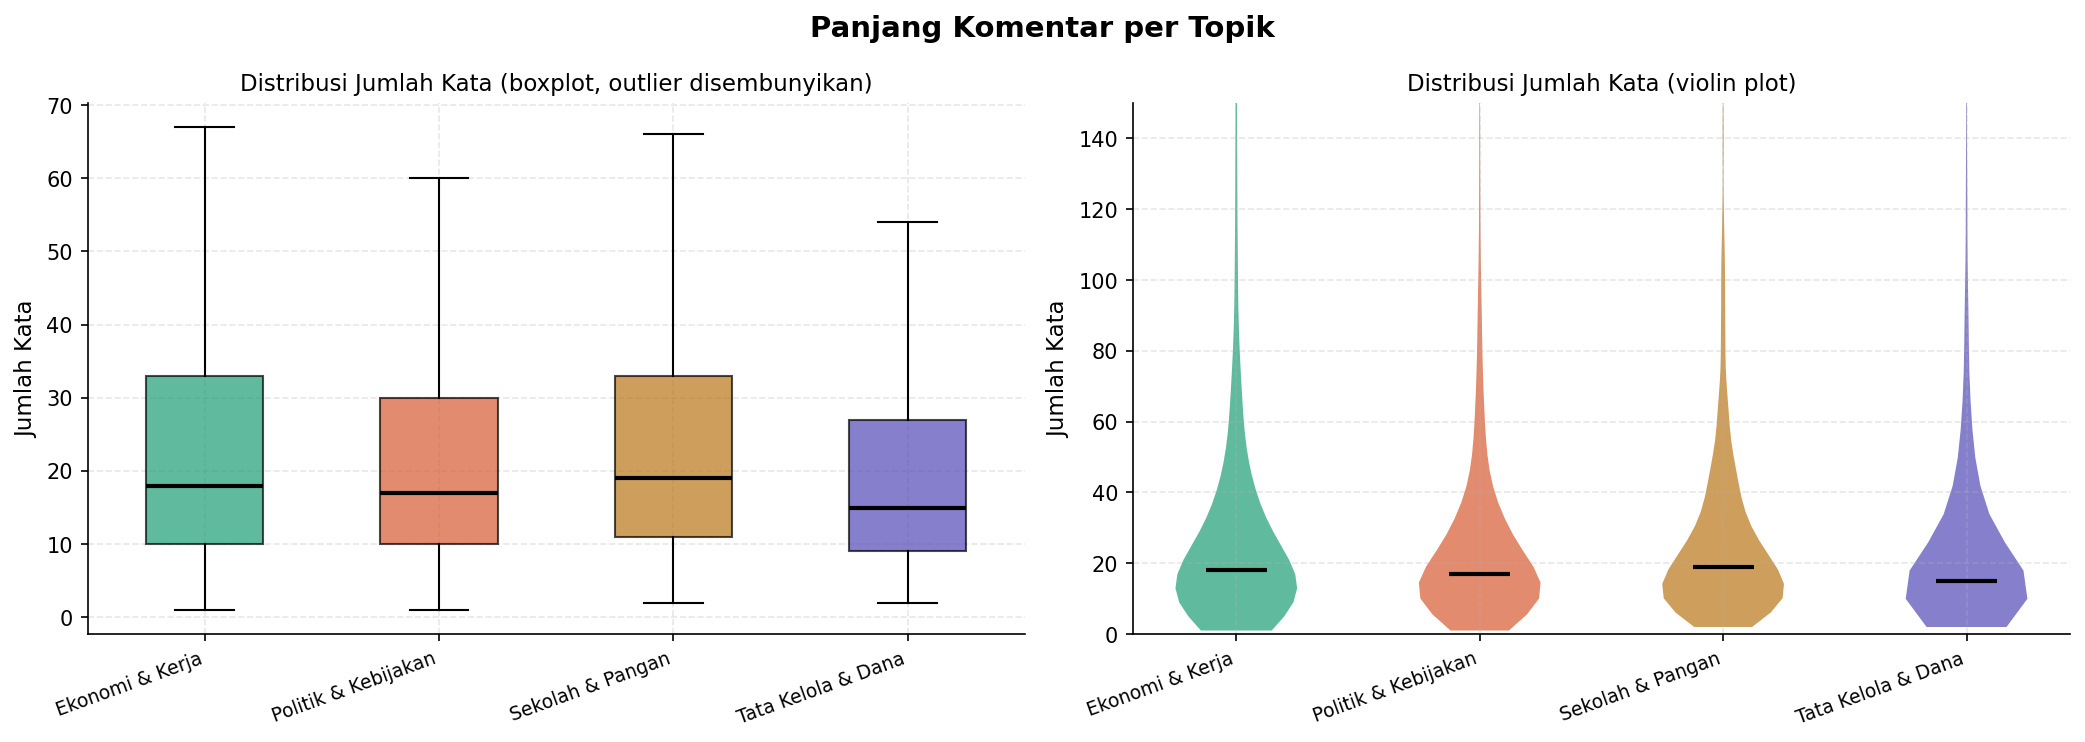

✓ Disimpan: fig7_panjang_komentar.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Panjang Komentar per Topik', fontsize=14, fontweight='bold')

# ── Panel kiri: Boxplot word count ───────────────────────────────────────────
ax1 = axes[0]
data_by_topic = [
    df[df['dominant_topic'] == t]['word_count'].dropna().values
    for t in range(4)
]
bp = ax1.boxplot(
    data_by_topic,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    showfliers=False,
    widths=0.5
)
for patch, topic_id in zip(bp['boxes'], range(4)):
    patch.set_facecolor(TOPIC_COLORS[topic_id])
    patch.set_alpha(0.7)

ax1.set_xticklabels([TOPIC_LABELS_SHORT[i] for i in range(4)],
                    rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Jumlah Kata', fontsize=11)
ax1.set_title('Distribusi Jumlah Kata (boxplot, outlier disembunyikan)', fontsize=11)

# ── Panel kanan: Violin plot ─────────────────────────────────────────────────
ax2 = axes[1]
parts = ax2.violinplot(
    data_by_topic,
    positions=range(4),
    showmedians=True,
    showextrema=False,
)
for pc, topic_id in zip(parts['bodies'], range(4)):
    pc.set_facecolor(TOPIC_COLORS[topic_id])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax2.set_xticks(range(4))
ax2.set_xticklabels([TOPIC_LABELS_SHORT[i] for i in range(4)],
                    rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Jumlah Kata', fontsize=11)
ax2.set_title('Distribusi Jumlah Kata (violin plot)', fontsize=11)
ax2.set_ylim(0, 150)

plt.tight_layout()
plt.savefig('fig7_panjang_komentar.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig7_panjang_komentar.png')

## 8. Ringkasan Statistik & Tabel Laporan

In [11]:
# ── Tabel ringkasan per topik ────────────────────────────────────────────────
rows = []
for topic_id in range(4):
    sub = df[df['dominant_topic'] == topic_id]
    rows.append({
        'Topik': topic_id,
        'Label': TOPIC_LABELS_SHORT[topic_id],
        'N Komentar': len(sub),
        '% Total': f"{len(sub)/len(df)*100:.1f}%",
        'Mean Prob': f"{sub['dominant_topic_probability'].mean():.3f}",
        'Median Prob': f"{sub['dominant_topic_probability'].median():.3f}",
        '% Prob ≥0.80': f"{(sub['dominant_topic_probability']>=0.80).mean()*100:.1f}%",
        'Median Kata': f"{sub['word_count'].median():.0f}",
    })

summary_df = pd.DataFrame(rows)
print('=== RINGKASAN STATISTIK PER TOPIK ===')
print(summary_df.to_string(index=False))
print()

# ── Tampilkan sebagai tabel Pandas styled ────────────────────────────────────
styled = summary_df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12px',
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                  ('font-weight', 'bold'),
                                  ('text-align', 'center')]}
])
styled

=== RINGKASAN STATISTIK PER TOPIK ===
 Topik               Label  N Komentar % Total Mean Prob Median Prob % Prob ≥0.80 Median Kata
     0     Ekonomi & Kerja        1458   21.4%     0.767       0.810        53.9%          18
     1 Politik & Kebijakan        1381   20.3%     0.777       0.833        55.3%          17
     2    Sekolah & Pangan        2387   35.1%     0.799       0.865        60.9%          19
     3  Tata Kelola & Dana        1579   23.2%     0.772       0.808        54.1%          15



,Topik,Label,N Komentar,% Total,Mean Prob,Median Prob,% Prob ≥0.80,Median Kata
0,0,Ekonomi & Kerja,1458,21.4%,0.767,0.810,53.9%,18
1,1,Politik & Kebijakan,1381,20.3%,0.777,0.833,55.3%,17
2,2,Sekolah & Pangan,2387,35.1%,0.799,0.865,60.9%,19
3,3,Tata Kelola & Dana,1579,23.2%,0.772,0.808,54.1%,15


In [12]:
# ── Ringkasan per sumber ─────────────────────────────────────────────────────
print('=== DISTRIBUSI TOPIK PER SUMBER (%) ===')
ct = pd.crosstab(
    df['source'],
    df['topic_label_short'],
    margins=True,
    margins_name='Total'
)
print(ct)
print()

# ── Confidence category breakdown ────────────────────────────────────────────
print('=== KATEGORI KEPERCAYAAN PENUGASAN TOPIK ===')
conf_ct = pd.crosstab(
    df['topic_label_short'],
    df['confidence_cat'],
    normalize='index'
) * 100
conf_ct = conf_ct.round(1)
# Urutkan kolom
col_order = ['Tinggi (≥0.80)', 'Sedang (0.60–0.80)', 'Rendah (<0.60)']
col_order_exist = [c for c in col_order if c in conf_ct.columns]
print(conf_ct[col_order_exist].to_string())

=== DISTRIBUSI TOPIK PER SUMBER (%) ===
topic_label_short  Ekonomi & Kerja  Politik & Kebijakan  Sekolah & Pangan  \
source                                                                      
BBC                            513                  122               191   
CNN                            750                  985              1926   
Merdeka                         77                   88                82   
Pandji                         104                  169               175   
Tempodotco                      14                   17                13   
Total                         1458                 1381              2387   

topic_label_short  Tata Kelola & Dana  Total  
source                                        
BBC                               213   1039  
CNN                              1168   4829  
Merdeka                            41    288  
Pandji                            131    579  
Tempodotco                         26     70  
Total         

## 9. Visualisasi Kepercayaan Penugasan

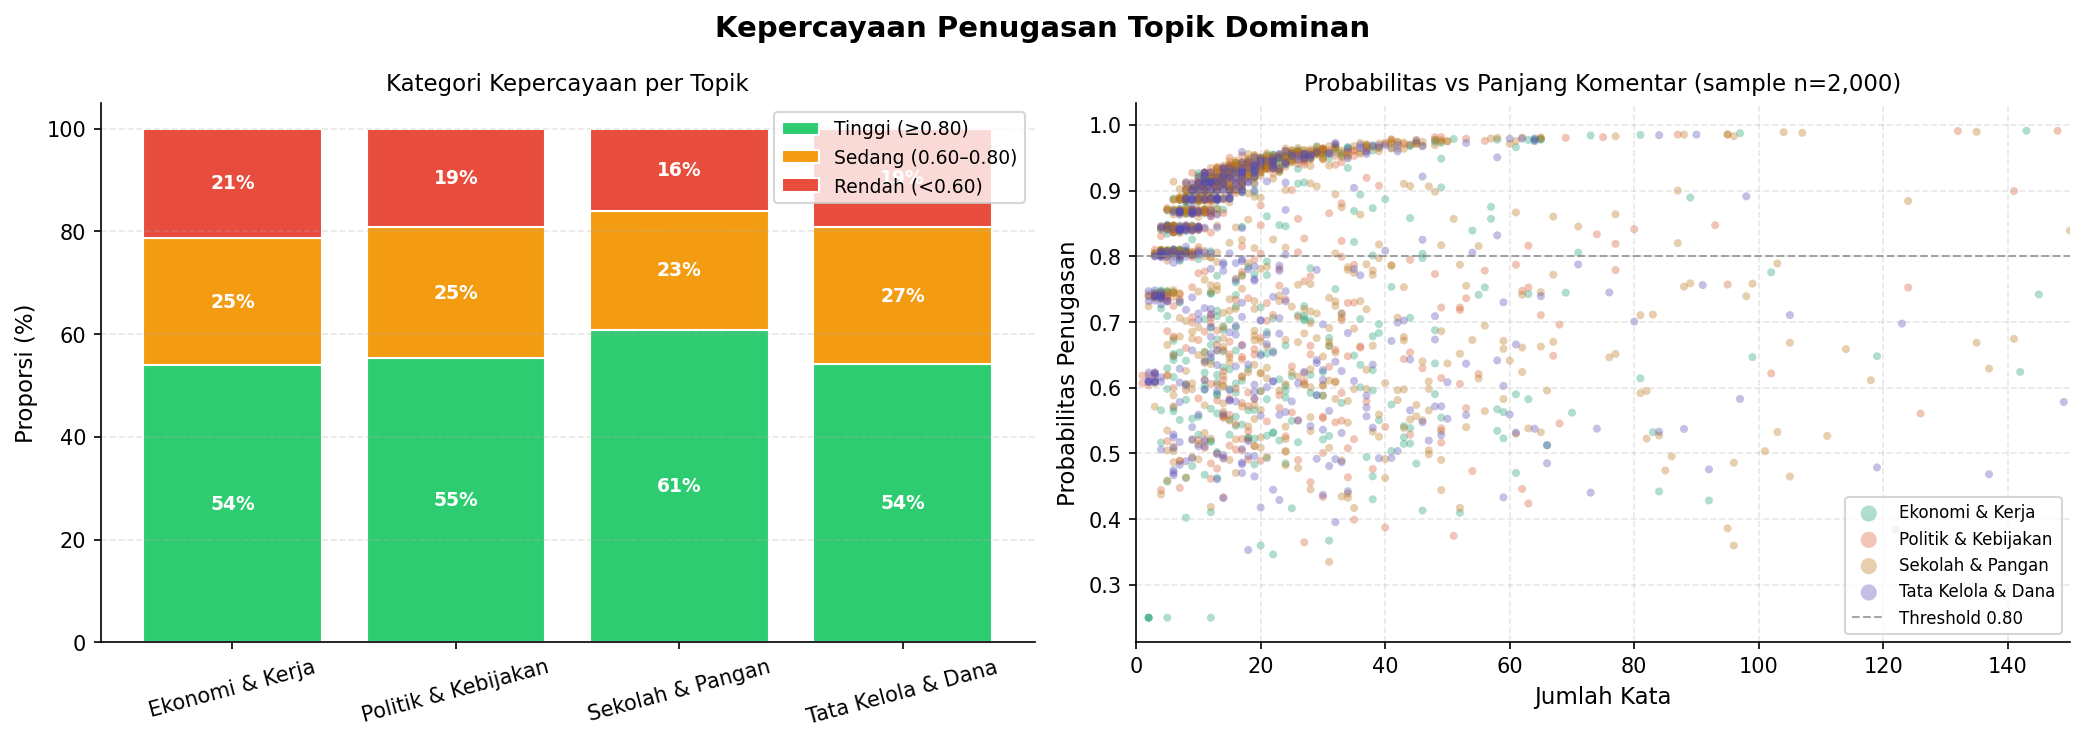

✓ Disimpan: fig8_kepercayaan_penugasan.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kepercayaan Penugasan Topik Dominan', fontsize=14, fontweight='bold')

# ── Panel kiri: Stacked bar confidence category per topik ────────────────────
ax1 = axes[0]
conf_colors = {
    'Tinggi (≥0.80)': '#2ECC71',
    'Sedang (0.60–0.80)': '#F39C12',
    'Rendah (<0.60)': '#E74C3C',
}
col_order = ['Tinggi (≥0.80)', 'Sedang (0.60–0.80)', 'Rendah (<0.60)']

conf_data = pd.crosstab(
    df['dominant_topic'],
    df['confidence_cat'],
    normalize='index'
) * 100
col_order_exist = [c for c in col_order if c in conf_data.columns]
conf_data = conf_data[col_order_exist]

bottom = np.zeros(4)
for cat in col_order_exist:
    vals = conf_data[cat].values
    bars = ax1.bar(
        [TOPIC_LABELS_SHORT[i] for i in range(4)],
        vals, bottom=bottom,
        color=conf_colors[cat], label=cat,
        edgecolor='white'
    )
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 8:
            ax1.text(
                bar.get_x() + bar.get_width()/2,
                bot + val/2,
                f'{val:.0f}%',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )
    bottom += vals

ax1.set_ylim(0, 105)
ax1.set_ylabel('Proporsi (%)', fontsize=11)
ax1.set_title('Kategori Kepercayaan per Topik', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='x', alpha=0)

# ── Panel kanan: Scatter probabilitas vs word count ──────────────────────────
ax2 = axes[1]
sample = df.sample(min(2000, len(df)), random_state=42)
for topic_id in range(4):
    sub = sample[sample['dominant_topic'] == topic_id]
    ax2.scatter(
        sub['word_count'],
        sub['dominant_topic_probability'],
        c=TOPIC_COLORS[topic_id],
        label=TOPIC_LABELS_SHORT[topic_id],
        alpha=0.35, s=15, edgecolors='none'
    )

ax2.axhline(0.80, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Threshold 0.80')
ax2.set_xlabel('Jumlah Kata', fontsize=11)
ax2.set_ylabel('Probabilitas Penugasan', fontsize=11)
ax2.set_title('Probabilitas vs Panjang Komentar (sample n=2,000)', fontsize=11)
ax2.set_xlim(0, 150)
ax2.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('fig8_kepercayaan_penugasan.png', bbox_inches='tight')
plt.show()
print('✓ Disimpan: fig8_kepercayaan_penugasan.png')

## 10. Contoh Komentar Representatif per Topik

In [14]:
# Ambil 3 komentar dengan probabilitas tertinggi per topik (paling representatif)
for topic_id in range(4):
    print('=' * 70)
    print(f'TOPIK {topic_id}: {TOPIC_LABELS_SHORT[topic_id].upper()}')
    print('=' * 70)
    top3 = (df[df['dominant_topic'] == topic_id]
            .nlargest(3, 'dominant_topic_probability')
            [['Comment', 'dominant_topic_probability', 'source', 'Date']])
    for i, (_, row) in enumerate(top3.iterrows(), 1):
        print(f'\n[{i}] Prob: {row["dominant_topic_probability"]:.4f} | Sumber: {row["source"]} | Tgl: {str(row["Date"])[:10]}')
        # Potong komentar panjang
        comment = str(row['Comment'])
        if len(comment) > 280:
            comment = comment[:280] + '...'
        print(f'   "{comment}"')
    print()

TOPIK 0: EKONOMI & KERJA

[1] Prob: 0.9968 | Sumber: Pandji | Tgl: 2025-10-13
   "Usul untuk Pak Prabbowo, jika masuk akal, supaya pemerintah ciptakan setidaknya 20 juta lapangan kerja untuk rakyat menengah ke bawah, dengan gaji, mungkin 1,2 -1,5 juta (1/2 UMR alias paruh waktu supaya fleksibel cari tambahan lain di waktu lainnya), kuota 1 lowongan kerja per k..."

[2] Prob: 0.9961 | Sumber: BBC | Tgl: 2026-01-09
   "inilah yang disebut berita yang benar berita yang turun langsung ke lapangan saya pedagang pasar dan sejak program mbg berjalan pasar tradisional terasa semakin sepi dan lesu bukan hanya kami di pasar yang terdampak pedagang sayur keliling pun ikut merasakan hal yang sama sebelum..."

[3] Prob: 0.9960 | Sumber: BBC | Tgl: 2026-01-09
   "saya pedagang pasar dan sejak program mbg berjalan pasar tradisional terasa semakin sepi dan lesu bukan hanya kami di pasar yang terdampak pedagang sayur keliling pun ikut merasakan hal yang sama sebelumnya para ibu masih rutin berbelanja u

## 11. Ekspor Dataset Berlabel

In [15]:
# ── Ekspor CSV lengkap berlabel ───────────────────────────────────────────────
export_cols = [
    'Username', 'Date', 'source', 'Comment', 'processed_comment',
    'word_count', 'comment_length',
    'dominant_topic', 'topic_label_short', 'topic_label',
    'dominant_topic_probability', 'confidence_cat'
]
df_export = df[export_cols].copy()
df_export.to_csv('comments_labeled_final.csv', index=False, encoding='utf-8-sig')

print(f'✓ Dataset berlabel diekspor: comments_labeled_final.csv')
print(f'  Jumlah baris : {len(df_export):,}')
print(f'  Jumlah kolom : {len(df_export.columns)}')
print()
print('Kolom yang tersedia:')
for col in df_export.columns:
    print(f'  - {col}')

✓ Dataset berlabel diekspor: comments_labeled_final.csv
  Jumlah baris : 6,805
  Jumlah kolom : 12

Kolom yang tersedia:
  - Username
  - Date
  - source
  - Comment
  - processed_comment
  - word_count
  - comment_length
  - dominant_topic
  - topic_label_short
  - topic_label
  - dominant_topic_probability
  - confidence_cat


In [16]:
# ── Ringkasan akhir ───────────────────────────────────────────────────────────
print('=' * 60)
print('RINGKASAN AKHIR ANALISIS TOPIK MBG')
print('=' * 60)
print(f'Total komentar dianalisis : {len(df):,}')
print(f'Rentang waktu             : {df["Date"].min().date()} – {df["Date"].max().date()}')
print(f'Jumlah sumber             : {df["source"].nunique()} channel YouTube')
print(f'Mean probabilitas global  : {df["dominant_topic_probability"].mean():.3f}')
print(f'% prob ≥ 0.80 (global)    : {(df["dominant_topic_probability"]>=0.80).mean()*100:.1f}%')
print()
print('Topik dengan komentar terbanyak:')
top_topic = df['dominant_topic'].value_counts().idxmax()
print(f'  → Topik {top_topic}: {TOPIC_LABELS_SHORT[top_topic]} '
      f'({df["dominant_topic"].value_counts()[top_topic]:,} komentar, '
      f'{df["dominant_topic"].value_counts()[top_topic]/len(df)*100:.1f}%)')
print()
print('File yang dihasilkan:')
files = [
    'fig1_distribusi_topik.png',
    'fig2_distribusi_probabilitas.png',
    'fig3_heatmap_sumber_topik.png',
    'fig4_stacked_bar_sumber.png',
    'fig5_tren_temporal.png',
    'fig6_wordcloud_topik.png',
    'fig7_panjang_komentar.png',
    'fig8_kepercayaan_penugasan.png',
    'comments_labeled_final.csv',
]
for f in files:
    print(f'  ✓ {f}')

RINGKASAN AKHIR ANALISIS TOPIK MBG
Total komentar dianalisis : 6,805
Rentang waktu             : 2025-01-05 – 2026-06-01
Jumlah sumber             : 5 channel YouTube
Mean probabilitas global  : 0.781
% prob ≥ 0.80 (global)    : 56.7%

Topik dengan komentar terbanyak:
  → Topik 2: Sekolah & Pangan (2,387 komentar, 35.1%)

File yang dihasilkan:
  ✓ fig1_distribusi_topik.png
  ✓ fig2_distribusi_probabilitas.png
  ✓ fig3_heatmap_sumber_topik.png
  ✓ fig4_stacked_bar_sumber.png
  ✓ fig5_tren_temporal.png
  ✓ fig6_wordcloud_topik.png
  ✓ fig7_panjang_komentar.png
  ✓ fig8_kepercayaan_penugasan.png
  ✓ comments_labeled_final.csv
